<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/Logistic_Regression_Campaign_Effectiveness_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# =============================================================================
# Logistic Regression
# =============================================================================
# =============================================================================
# Business Case --
#The dataset comes from the UCI Machine Learning repository, and it is related to direct marketing campaigns (phone calls) of a Portuguese banking.
#The classification goal is to predict whether the client will subscribe (1/0) to a term deposit (variable y).
# =============================================================================
# Setting the Environment
# =============================================================================
import os
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

In [20]:
# =============================================================================
# # Importing the dataset
# =============================================================================

data = pd.read_csv('/content/sample_data/Banking.csv', header=0)
data = data.dropna()
print(data.shape)
print(list(data.columns))


(41188, 21)
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']


In [21]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


# EDA

/tmp/ipykernel_6254/4272616604.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y',data=data, palette='hls')


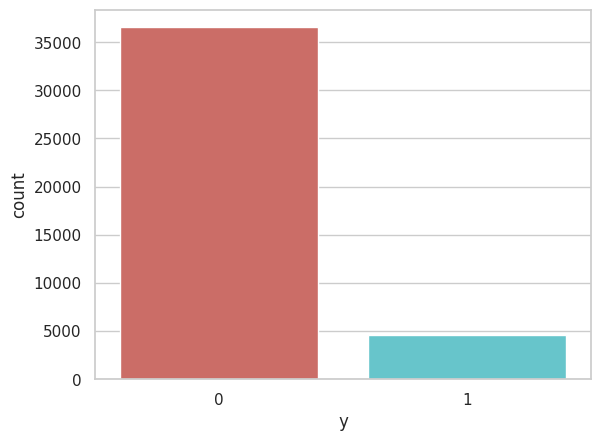

In [23]:
# =============================================================================
# # Exploratory Data Analysis
# =============================================================================


# =============================================================================
# 1. Predict variable (desired target)
# y — has the client subscribed a term deposit? (binary: “1”, means “Yes”, “0” means “No”)
# =============================================================================

#Barplot for the dependent variable
sns.countplot(x='y',data=data, palette='hls')
plt.show()


In [24]:
#Check the missing values
data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


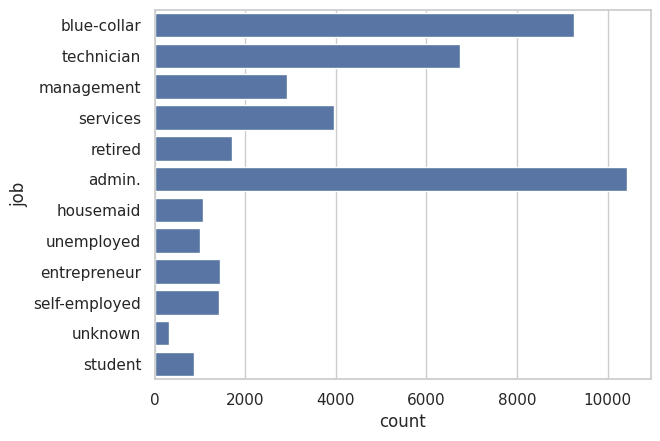

In [25]:
#Customer job distribution
sns.countplot(y="job", data=data)
plt.show()

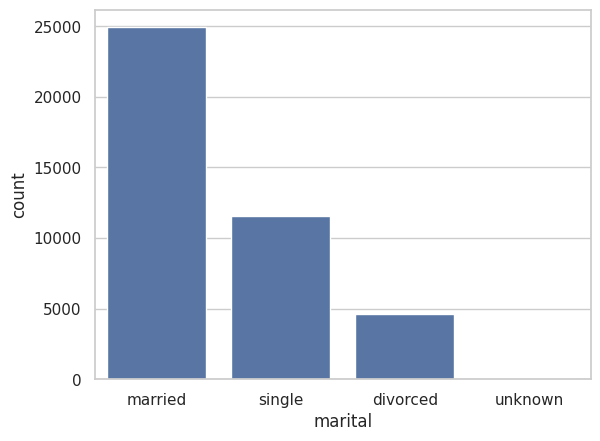

In [26]:
#Customer marital status distribution
sns.countplot(x="marital", data=data)
plt.show()

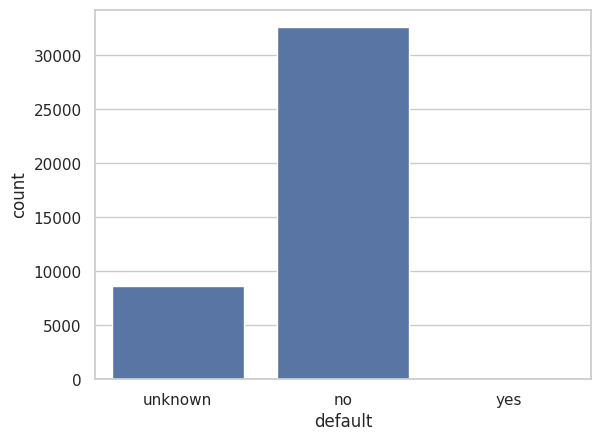

In [27]:
#Barplot for credit in default
sns.countplot(x="default", data=data)
plt.show()


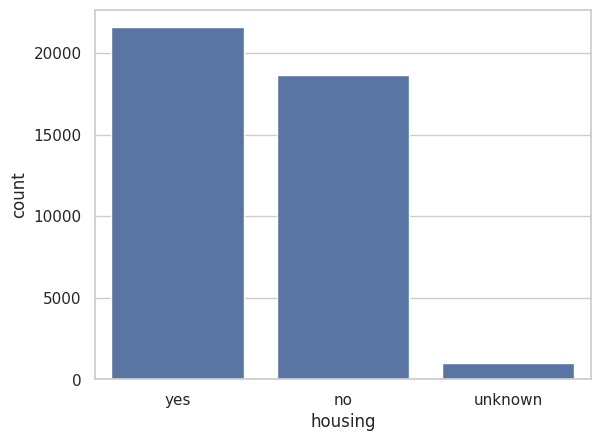

In [28]:
#Barplot for housing loan
sns.countplot(x="housing", data=data)
plt.show()

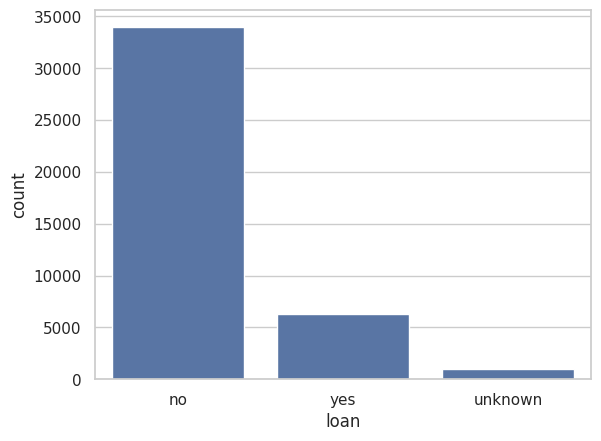

In [29]:
#Barplot for personal loan
sns.countplot(x="loan", data=data)
plt.show()

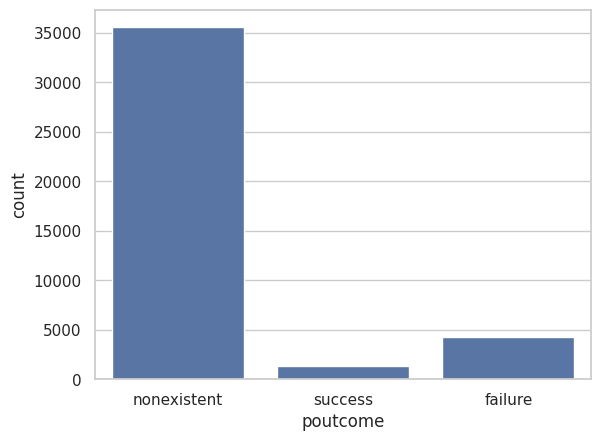

In [30]:
#Barplot for previous marketing loan outcome
sns.countplot(x="poutcome", data=data)
plt.show()

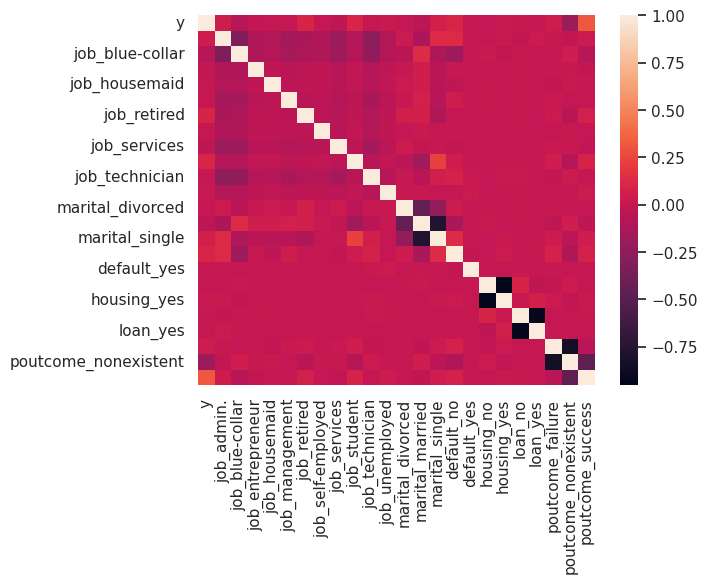

In [31]:
# =============================================================================
# Our prediction will be based on the customer’s job, marital status, whether he(she) has credit in default,
#whether he(she) has a housing loan, whether he(she) has a personal loan, and the outcome of the previous marketing campaigns.
#So, we will drop the variables that we do not need.
# =============================================================================


#Dropping the redant columns
data.drop(data.columns[[0, 3, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19]], axis=1, inplace=True)

#Creating Dummy Variables
data2 = pd.get_dummies(data, columns =['job', 'marital', 'default', 'housing', 'loan', 'poutcome'])

#Drop the unknown columns
data2.drop(data2.columns[[12, 16, 18, 21, 24]], axis=1, inplace=True)
data2.columns

#Check the independence between the independent variables
sns.heatmap(data2.corr())
plt.show()


In [32]:
# =============================================================================
# Split the data into training and test sets
# =============================================================================
X = data2.iloc[:,1:]
y = data2.iloc[:,0]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
X_train.shape

(30891, 23)

In [33]:
# =============================================================================
# Fitting the Logistic Model
# =============================================================================
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
y_pred_train = classifier.predict(X_train)

In [34]:
# =============================================================================
# Evaluating the Logistic Model
# =============================================================================


from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_train = confusion_matrix(y_train,y_pred_train)

print(cm_train)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(classifier.score(X_test, y_test)))


from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

[[27048   344]
 [ 2852   647]]
Accuracy of logistic regression classifier on test set: 0.90
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      9156
           1       0.68      0.20      0.31      1141

    accuracy                           0.90     10297
   macro avg       0.79      0.59      0.63     10297
weighted avg       0.88      0.90      0.88     10297



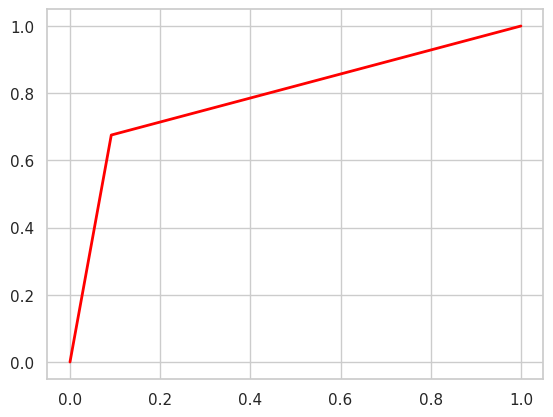

In [35]:
# =============================================================================
# Interpretation:Interpretation: Of the entire test set, 88% of the promoted term deposit were the term deposit that the customers liked. Of the entire test set, 90% of the customer’s preferred term deposits that were promoted.
# =============================================================================


##Computing false and true positive rates
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr,_=roc_curve(classifier.predict(X_test),y_test,drop_intermediate=False)

import matplotlib.pyplot as plt
##Adding the ROC
##Random FPR and TPR

##Title and label
plt.plot(fpr, tpr, color='red',
 lw=2, label='ROC curve')

In [36]:
roc_auc_score(classifier.predict(X_test),y_test)

np.float64(0.7919657843177333)